<a href="https://colab.research.google.com/github/GReginatto/GAIA_Nivelamento/blob/main/Nivelamente2_0_GustavoReginatto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NÍVEL 2.1 – Data Augmentation

Data Augmentation se refere a um conjunto de técnicas usadas para aumentar a quantidade e a diversidade de dados de treinamento, criando novas variações de dados existentes. Isso ajuda a melhorar a robustez e a generalização de modelos de machine learning.

Flip (Inverter): Consiste em espelhar a imagem horizontalmente ou verticalmente. Por exemplo, inverter a imagem de um gato horizontalmente ainda resulta na imagem de um gato, mas com uma orientação diferente, o que ajuda o modelo a reconhecer o objeto independentemente de sua orientação horizontal.

Rotate (Rotacionar): Gira a imagem por um determinado ângulo. Isso ajuda o modelo a ser invariante à rotação do objeto na imagem.

Crop (Recortar): Seleciona uma parte da imagem original. Pode ser um recorte aleatório ou central. Isso força o modelo a focar em diferentes partes da imagem e a ser menos sensível à posição exata do objeto.

Zoom (Aplicar Zoom): Amplia ou reduz uma parte da imagem. Isso ajuda o modelo a reconhecer objetos em diferentes escalas.

Shift (Deslocar): Move a imagem horizontalmente ou verticalmente. Isso ajuda o modelo a ser menos sensível à posição do objeto dentro da imagem.

CÓDIGO IA PRA EXEMPLIFICAR

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Cria uma imagem de exemplo (uma matriz simples representando uma imagem em tons de cinza)
image = tf.constant([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=tf.float32)
image = tf.expand_dims(image, axis=-1) # Adiciona um canal para compatibilidade com as funções de imagem do TF
image = tf.expand_dims(image, axis=0)  # Adiciona uma dimensão de batch

print("Imagem original:")
print(image[0, ..., 0].numpy()) # Exibe a imagem sem as dimensões adicionais

# Exemplo de Flip (Horizontal)
flipped_image = tf.image.flip_left_right(image)
print("\nImagem invertida horizontalmente:")
print(flipped_image[0, ..., 0].numpy())

# Exemplo de Rotate (90 graus)
rotated_image = tf.image.rot90(image)
print("\nImagem rotacionada em 90 graus:")
print(rotated_image[0, ..., 0].numpy())

# Para demonstrações mais visuais com imagens reais, você pode carregar uma imagem usando bibliotecas como OpenCV ou PIL.
# Exemplo (não executado):
# import cv2
# img = cv2.imread('sua_imagem.jpg')
# img = tf.constant(img, dtype=tf.float32)
# img = tf.expand_dims(img, axis=0)
# flipped_img_real = tf.image.flip_left_right(img)
# plt.imshow(tf.cast(flipped_img_real[0], tf.uint8))
# plt.title("Imagem real invertida")
# plt.axis('off')
# plt.show()

# NÍVEL 2.2 – Regularização e Generalização

Dropout: Durante o treinamento alguns neurônios podem ser desligados aleatoriamente, pra fazer a rede não depender demais de alguns neurônios específicos, forçando redundância e robustez. (Reduz overfitting).

Batch Normalization (BatchNorm): Normaliza as ativações dentro de cada minibatch (Média 0, variância = 1), seguido de uma transformação linear. Evita que valores explodam ou fiquem muito pequenos, reduzidno o covariate shift interno. (Acelera o treinamento, atua como regulizador leve, permite usar taxa de aprendizado maior).

L2 Regularization (Weight Decay): Penaliza pesos grandes adicionando o termo λ∥W∥2 2 (Incentiva a rede a manter pesos menores, modelos mais simples pra ter menos overfitting).

DropConnect: Variante do dropout, mas em vez de zerar os neurônios você zera as conexões (Pesos) aleatoriamente, deixa mais granular mas é mais caro computacionalmente.

Spectral Normalization: Normaliza os pesos de cada camada usando a norma espectral (O maior valor singular da matriz de pesos). Melhor a estabilidade do treinamento adversarial (Evita explosões/colapsos no discriminador da GANs).

RESUMINDO:

​Dropout → desliga neurônios aleatórios.

BatchNorm → normaliza ativações em cada batch.

L2 → mantém pesos pequenos.

DropConnect → desliga conexões aleatórias.

SpectralNorm → limita a "força máxima" de cada camada (estabilidade, especialmente em GANs).


In [ ]:

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout = nn.Dropout(p=0.5)   # 50% dos neurônios desligados no treino
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.dropout(x)   # só aplica no treino
        return self.fc2(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)  # normaliza os canais
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

    def forward(self, x):
        x = nn.ReLU()(self.bn1(self.conv1(x)))
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        return

model = MLP()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# weight_decay aplica L2 nos pesos automaticamente

class DropConnectLinear(nn.Linear):
    def __init__(self, in_features, out_features, p=0.5):
        super().__init__(in_features, out_features)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.bernoulli((1 - self.p) * torch.ones_like(self.weight))
            weight = self.weight * mask  # zera conexões aleatórias
        else:
            weight = self.weight * (1 - self.p)
        return F.linear(x, weight, self.bias)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = spectral_norm(nn.Linear(784, 256))
        self.fc2 = spectral_norm(nn.Linear(256, 1))

    def forward(self, x):
        x = nn.LeakyReLU(0.2)(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

# NÍVEL 2.3 – Redes Convolucionais (CNNs)

As Redes Convolucionais (CNNs) foram projetadas para processar dados que possuem estrutura espacial (ex: imagens, áudio, vídeo). Diferem de redes totalmente conectadas por explorarem localidade, compartilhamento de pesos e hierarquia de características.

Filtros / Kernels: São pequenas matrizes (ex: 3×3, 5×5) que "varrem" a entrada, multiplicando valores locais. Cada filtro aprende a detectar um padrão específico (bordas, texturas, formas). Uma camada pode ter dezenas ou centenas de filtros, produzindo diferentes mapas de ativação.

Stride: Define de quantos pixels o kernel "anda" a cada passo. Stride=1 → maior resolução na saída, mais sobreposição. Stride=2 → reduz dimensões, parecido com pooling.

Padding: Adiciona bordas artificiais (zeros normalmente). Evita que a saída encolha a cada convolução. Same padding → mantém altura/largura.Valid padding → sem bordas, saída menor.

Poooling: Operações para reduzir a dimensão espacial:
Max pooling: pega o valor máximo → bom para captar características fortes.
Average pooling: pega a média → suaviza informações.
Global average pooling: transforma cada mapa de ativação em um único valor médio → substitui camadas fully connected em muitas CNNs modernas.

Dilated Convolution: Introduz lacunas no kernel (Dilatação), permite capturar o campo receptivo maior sem aumentar os parâmetros (Muito usado em segmentação semântica).

Separable Convolution: Divide uma convolução normal em duas etapas: Depthwise: aplica um kernel em cada canal separadamente. Pointwise (1×1): combina resultados entre canais. Reduz drasticamente o custo computacional. Base de arquiteturas como MobileNet.

Modelos CNN Clássicos

LeNet-5 (1998)

Primeira CNN de destaque, usada em reconhecimento de dígitos (MNIST).

Estrutura simples: conv → pooling → FC.

AlexNet (2012)

Revolucionou o ImageNet.

Introduziu ReLU, dropout, uso intensivo de GPUs.

Muito mais profunda que LeNet.

ZFNet (2013)

Ajustes de tamanho de filtros e stride em relação ao AlexNet.

Popularizou visualização de filtros internos.

VGG16 / VGG19 (2014)

Usou muitos filtros pequenos (3×3) em sequência.

Arquitetura profunda, mas com muitos parâmetros (~138M).

Simples e ainda bastante usada como base.

GoogLeNet / Inception (2014–2016)

Introduziu o Inception module: convoluções de diferentes tamanhos em paralelo.

Muito eficiente → boa acurácia com menos parâmetros.

Variantes: Inception v1 a v4, depois Inception-ResNet.

ResNet (2015)

Introduziu skip connections → identidade somada à saída de blocos.

Resolveu o problema de vanishing gradient em redes muito profundas.

Variantes: ResNet-18 até ResNet-152.

ResNeXt (2017)

Extensão da ResNet com cardinalidade (grupos de convolução).

Mais eficiente em precisão/complexidade.

DenseNet (2017)

Cada camada conecta-se a todas as seguintes (conexões densas).

Reaproveita melhor as features → menos parâmetros para boa performance.

WideResNet (2016)

Variante da ResNet que aumenta largura em vez de profundidade.

Mais fácil de treinar e eficiente em datasets menores.

Modelos Eficientes e Leves (focados em dispositivos móveis / IoT)
MobileNet (V1–V3, 2017–2019)

Baseada em depthwise separable convolutions.

Leve e rápida → ideal para celulares.

V2: adicionou bottleneck + skip connections.

V3: usou Neural Architecture Search para otimização automática.

SqueezeNet (2016)

Famosa pelo tamanho minúsculo (~50x menor que AlexNet).

Usa fire modules (1×1 seguido de 3×3) para compactação.

ShuffleNet (2017)

Introduziu channel shuffling com convoluções agrupadas.

Extremamente eficiente em dispositivos com restrições.

EfficientNet (2019)

Introduziu compound scaling: balanceia profundidade, largura e resolução da imagem.

Versões B0–B7 variam do mais leve ao mais preciso.

Muito eficiente comparado a modelos anteriores.

EfficientNetV2 (2021)

Mais rápido no treino e com melhor uso de GPU/TPU modernas.

Melhor adaptado para datasets grandes.

GhostNet (2020)

Reduz convoluções pesadas gerando “ghost features” → mais leves de calcular.

Ainda competitivo em precisão.

TinyML

Não é um modelo, mas uma área.

Conjunto de arquiteturas CNN otimizadas para rodar em microcontroladores e dispositivos embarcados.

Aplicações: IoT, sensores inteligentes, wearables.


# NÍVEL 2.4 – Transformers para Visão

Transformers nasceram no NLP (“Attention is All You Need”, 2017), mas a ideia foi adaptada para imagens a partir de 2020.
Em vez de convoluções, eles usam atenção para capturar dependências globais entre partes da entrada.

Attention (Atenção)

O mecanismo de atenção responde à pergunta: “onde devo focar para entender melhor este elemento da entrada?”

Ele funciona assim:

Cada elemento é representado por três vetores: Query (Q), Key (K) e Value (V).

A relevância de um elemento em relação a outro é calculada pelo produto interno entre Query e Key.

O resultado é normalizado e usado para ponderar os Values correspondentes.

Fórmula:

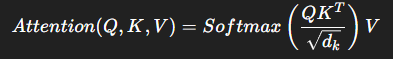


Multi-Head Attention

Em vez de calcular a atenção uma única vez, o Transformer cria múltiplas “cabeças” de atenção.

Cada cabeça aprende um tipo diferente de relação entre os elementos.

No fim, todas são concatenadas e projetadas juntas.
Isso enriquece a representação, pois diferentes cabeças podem olhar para diferentes padrões.

Self-Attention

É um caso especial da atenção onde Q, K e V vêm da mesma fonte.

Cada elemento da entrada (no caso de visão, cada patch da imagem) presta atenção em todos os outros.

Isso permite que a rede entenda relações de longo alcance, algo que convoluções tradicionais (limitadas ao campo receptivo local) capturam com mais dificuldade

Embeddings e Patches

No NLP, os tokens (palavras) são transformados em vetores (embeddings).
Na visão, a imagem é dividida em patches fixos (por exemplo, blocos de 16×16 pixels). Cada patch é achatado e transformado em um vetor de embedding.
Além disso, são adicionados positional encodings, pois os Transformers não têm noção de ordem ou posição espacial por si mesmos.

Layer Normalization

Cada bloco Transformer usa LayerNorm para estabilizar o treinamento.
O padrão é:

Normalizar → Atenção → Residual (skip connection)

Normalizar → MLP (rede totalmente conectada) → Residual

Isso ajuda o modelo a treinar redes muito profundas sem instabilidades.

Vision Transformer (ViT, 2020)

Primeira aplicação de Transformer puro em visão.

Pipeline:


1.   A imagem é dividida em patches.
2.   Cada patch é transformado em embedding + posição.
3.   Esses embeddings passam por várias camadas Transformer (atenção + MLP).
4.   Um token especial ([CLS]) resume toda a imagem para classificação.








Pontos fortes: arquitetura simples, conceito elegante.

Limitação: precisa de muito dado para treinar bem (em datasets pequenos, CNNs ainda se saem melhor).

Swin Transformer (2021)

Evolução do ViT, mais eficiente e adaptável a diferentes tarefas (classificação, detecção, segmentação).

Diferenças principais em relação ao ViT:

Atenção em janelas locais: em vez de olhar globalmente para todos os patches de uma vez (muito caro), divide a imagem em blocos menores.

Janela deslizante (shifted windows): entre camadas, as janelas se deslocam, permitindo que informações de diferentes regiões se comuniquem.

Hierarquia: a rede reduz progressivamente a resolução (como fazem as CNNs), criando representações em diferentes escalas.

Tornou-se muito usado como backbone em tarefas de visão modernas, superando CNNs tradicionais em vários benchmarks.

# NÍVEL 2.5 – Transfer Learning





Transfer Learning (Aprendizado por Transferência) é uma técnica onde um modelo pré-treinado em uma grande base de dados (como o ImageNet) é reaproveitado para uma nova tarefa, geralmente com menos dados disponíveis.

A ideia é simples:
em vez de treinar uma rede do zero — o que exige muito tempo, poder computacional e dados —, aproveitamos o conhecimento que ela já adquiriu em outra tarefa.

1. Feature Extraction (Extração de Características)

Nesta estratégia, mantemos congeladas as camadas convolucionais do modelo pré-treinado.
Essas camadas atuam como um extrator de características gerais (bordas, texturas, formas, padrões visuais).

Somente a parte final da rede (geralmente as camadas totalmente conectadas ou o classificador) é substituída e treinada novamente com os dados da nova tarefa.

👉 Ideal quando:

O dataset novo é pequeno.

O domínio das imagens é parecido com o dataset original (ex: fotos naturais).

Vantagem: treinamento rápido, evita overfitting.
Desvantagem: menos flexibilidade, pois o modelo não se adapta profundamente à nova tarefa.

2. Fine-Tuning (Ajuste Fino)

Aqui, descongelamos parte das camadas pré-treinadas (geralmente as últimas) e as re-treinamos com taxa de aprendizado baixa.

Isso permite que o modelo ajuste seus pesos às particularidades da nova base de dados, sem perder o conhecimento geral aprendido antes.

👉 Ideal quando:

O novo dataset é maior.

A tarefa é diferente da original (ex: imagens médicas, satélites, desenhos).

Vantagem: melhor adaptação e desempenho.
Desvantagem: mais caro computacionalmente e pode causar overfitting se mal ajustado.

🔹 Modelos Clássicos Usados em Transfer Learning
Esses modelos vêm pré-treinados no ImageNet (1.2 milhão de imagens, 1000 classes) e são amplamente usados em frameworks como PyTorch e Keras.

🧠 VGG16 / VGG19

Arquitetura simples: blocos de convoluções 3×3 seguidos de pooling e camadas densas.

Muito usada para feature extraction, por ser fácil de entender e adaptar.

Ponto fraco: muitos parâmetros (pesada e lenta).

⚡ ResNet (18, 34, 50, 101, 152)

Introduz os residual blocks, que permitem redes muito profundas sem degradar o desempenho.

Excelente para fine-tuning e tarefas genéricas.

Ainda é um backbone padrão em muitas aplicações.

📱 MobileNet (V1, V2, V3)

Projetada para dispositivos móveis: leve e eficiente.

Usa depthwise separable convolutions, que reduzem custo computacional.

Ótima para edge computing e TinyML.

🌀 DenseNet

Cada camada recebe como entrada o output de todas as camadas anteriores, o que melhora o fluxo de gradientes.

Muito eficiente em termos de parâmetros e generalização.

Ideal para fine-tuning em conjuntos menores.

🚀 EfficientNet (B0–B7, EfficientNetV2)

Baseada em um escalonamento balanceado de profundidade, largura e resolução.

Excelente custo-benefício entre precisão e desempenho.

Frequentemente usada como backbone em aplicações modernas de visão.

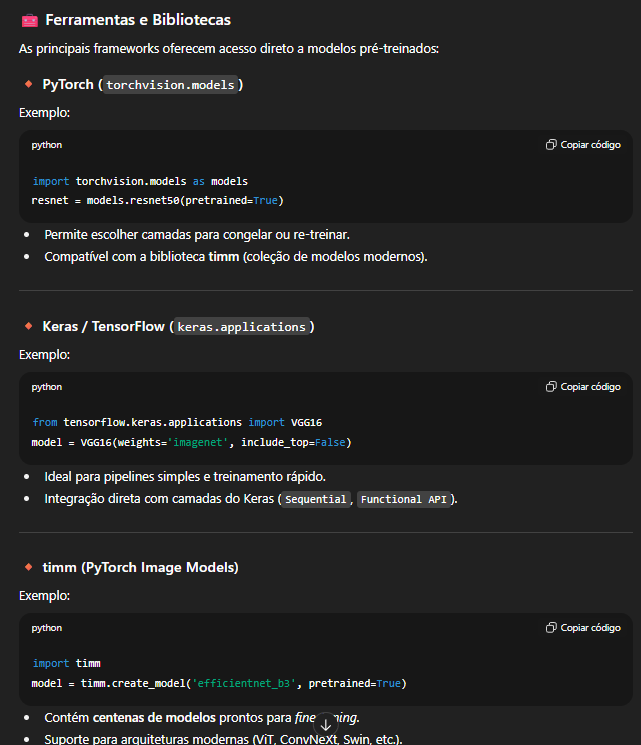

# PROJETO 01